In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import copy

In [2]:
students_records = pd.read_csv("./Student_Performance.csv")

In [3]:
students_records.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [4]:
students_records.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


In [5]:
students_records.describe()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


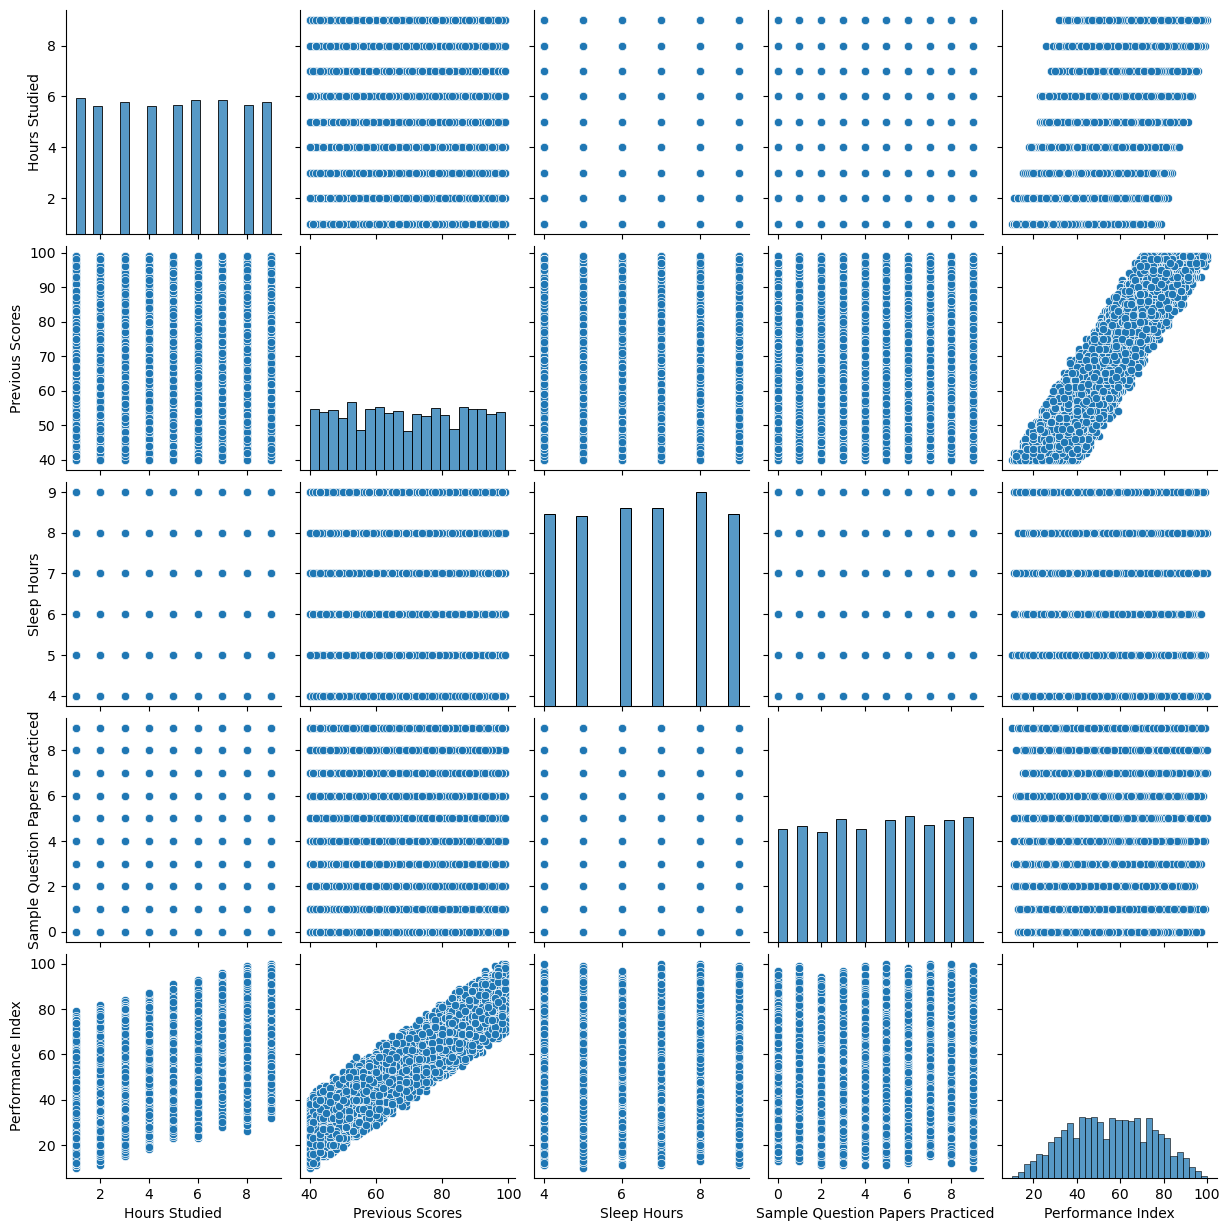

In [6]:
sns.pairplot(students_records)

<Axes: xlabel='Hours Studied', ylabel='Performance Index'>

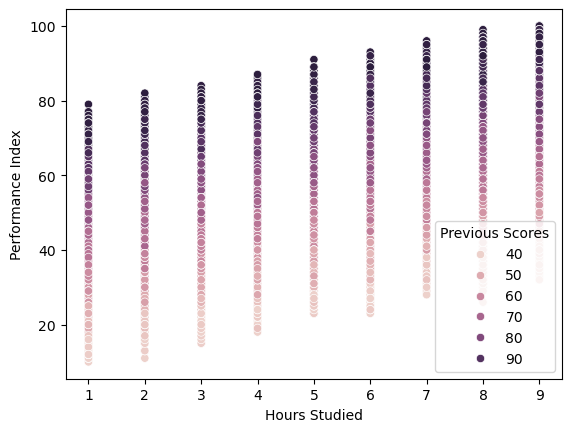

In [7]:
sns.scatterplot(data=students_records, x = "Hours Studied", y = "Performance Index", hue="Previous Scores")

In [9]:
students_records['ECA'] = students_records["Extracurricular Activities"]
print(students_records["ECA"])

0       Yes
1        No
2       Yes
3       Yes
4        No
       ... 
9995    Yes
9996    Yes
9997    Yes
9998    Yes
9999     No
Name: ECA, Length: 10000, dtype: object


In [10]:
students_records["ECA"]

0       Yes
1        No
2       Yes
3       Yes
4        No
       ... 
9995    Yes
9996    Yes
9997    Yes
9998    Yes
9999     No
Name: ECA, Length: 10000, dtype: object

In [11]:
students_records["ECA"] = students_records["ECA"].map({
    "Yes":1,
    "No":0
})

In [12]:
students_records.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index,ECA
0,7,99,Yes,9,1,91.0,1
1,4,82,No,4,2,65.0,0
2,8,51,Yes,7,2,45.0,1
3,5,52,Yes,5,2,36.0,1
4,7,75,No,8,5,66.0,0


In [13]:
students_records.drop(columns="Extracurricular Activities", inplace=True)

In [14]:
students_records.head()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index,ECA
0,7,99,9,1,91.0,1
1,4,82,4,2,65.0,0
2,8,51,7,2,45.0,1
3,5,52,5,2,36.0,1
4,7,75,8,5,66.0,0


In [51]:
X = students_records[[
    "Hours Studied",
    "Previous Scores",
    "Sleep Hours",
    "Sample Question Papers Practiced",
    "ECA",
]]
y = students_records["Performance Index"]

np.random.seed(42)
indices = np.random.permutation(len(X))
split = int(0.8 * len(X))

train_idx, test_idx = indices[:split], indices[split:]

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]


In [52]:
X_train

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,ECA
6252,5,69,8,2,0
4684,2,46,4,8,1
1731,7,56,7,5,1
4742,6,42,8,5,1
4521,7,53,4,6,0
...,...,...,...,...,...
1638,2,96,5,5,0
5891,1,66,8,7,0
7427,8,47,7,1,0
608,7,99,5,4,0


In [53]:
def compute_cost(X, y, w, b):
    """
    :param X: features (m,n)
    :param y: target (n,)
    :param w: model parameter (n,)
    :param b: model parameter (scalar)
    :return: scalar cost value
    """

    m = X.shape[0]
    cost = 0.0
    for i in range(m):
        f_wi = np.dot(X[i], w) + b
        cost = cost + (f_wi - y[i]) ** 2

    return cost / (2 * m)


In [54]:
def compute_gradient(X, y, w, b):
    """
    :param X: features (m,n)
    :param y: target (n,)
    :param w: model parameter (n,)
    :param b: model parameter (scalar)
    :return: tuple (gradient values)
    """

    m, n = X.shape
    dj_dw = np.zeros((n,))
    dj_db = 0.0
    for i in range(m):
        f_wi = np.dot(X[i], w) + b
        err = f_wi - y[i]
        for j in range(n):
            dj_dw[j] = dj_dw[j] + err * X[i, j]
        dj_db = dj_db + err

    return dj_dw / m, dj_db / m


In [55]:
def gradient_descent(X, y, w_in, b_in, gradient_function, learning_rate, num_itr):
    """
    :param X: features (m,n)
    :param y: target (n,)
    :param w_in: model parameter (n,)
    :param b_in: model parameter (scalar)
    :param gradient_function: compute gradient function from above
    :param learning_rate: scalar alpha value
    :param num_itr: scalar epochs value
    :return:
        w: (n,) updated w_in value
        b: scalar updated b_in value
    """

    w = np.array(w_in, dtype=float)
    b = float(b_in)

    for i in range(num_itr):
        # calculating the gradient descent
        dj_dw, dj_db = gradient_function(X, y, w, b)

        w = w - learning_rate * dj_dw
        b = b - learning_rate * dj_db

    return w, b


In [56]:
def normalize(X):
    """
    :param X: X_train : 2D array (n,)
    :return: X_norm: 2D array (n,)
    """

    X = np.asarray(X, dtype=float)
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)

    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma


In [57]:
X_train_norm, mu, sigma = normalize(X_train.to_numpy())


In [58]:
X_train_norm


array([[-0.00907786, -0.02174029,  0.85883624, -0.90162777, -1.00075028],
       [-1.16795378, -1.3485107 , -1.49716545,  1.19325257,  0.99925028],
       [ 0.76350608, -0.771654  ,  0.26983582,  0.1458124 ,  0.99925028],
       ...,
       [ 1.14979805, -1.29082503,  0.26983582, -1.25077449, -1.00075028],
       [ 0.76350608,  1.70882981, -0.90816503, -0.20333432, -1.00075028],
       [-0.00907786, -0.771654  ,  1.44783667,  0.49495912,  0.99925028]])

In [59]:
w_init = np.zeros(X_train_norm.shape[1], dtype=float)
b_init = 0.0

epochs = 1000
alpha = 1e-2

w, b = gradient_descent(X_train_norm, y_train.to_numpy(), w_init, b_init, compute_gradient, alpha, epochs)

print(f"the value of w is {w} and the value of b is {b}")

# print(y_train)


the value of w is [ 7.38072291 17.65790389  0.81244704  0.57701638  0.30756947] and the value of b is 55.23411537139239


In [60]:
def predict(x, w, b, mu, sigma):
    """
    :param x: (m,n)
    :param w: (n,)
    :param b: scalar
    :return: predicted student's performance index
    """

    x = np.asarray(x, dtype=float)
    x_norm = (x - mu) / sigma
    return np.dot(x_norm, w) + b


In [62]:
predict([9, 95, 8, 7 ,1], w, b, mu, sigma)


np.float64(94.16365150140109)

In [63]:
def mean_squared_error(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return np.mean((y_true - y_pred) ** 2)

train_preds = predict(X_train.to_numpy(), w, b, mu, sigma)
test_preds = predict(X_test.to_numpy(), w, b, mu, sigma)

print(f"train MSE: {mean_squared_error(y_train.to_numpy(), train_preds):.4f}")
print(f"test MSE: {mean_squared_error(y_test.to_numpy(), test_preds):.4f}")


train MSE: 4.1442
test MSE: 4.1839
